In [148]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.svm import SVC

from techniques import *


# Question 1

In [122]:
df = pd.read_csv('train.csv')
df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [123]:
train, test = train_test_split(df, test_size=0.1, stratify=df['target'], random_state=0)
print("Train size:", len(train), "Test size:", len(test))

Train size: 6851 Test size: 762


In [124]:
df.describe()

,id,target
count,7613.000000,7613.00000
mean,5441.934848,0.42966
std,3137.116090,0.49506
min,1.000000,0.00000
25%,2734.000000,0.00000
50%,5408.000000,0.00000
75%,8146.000000,1.00000
max,10873.000000,1.00000


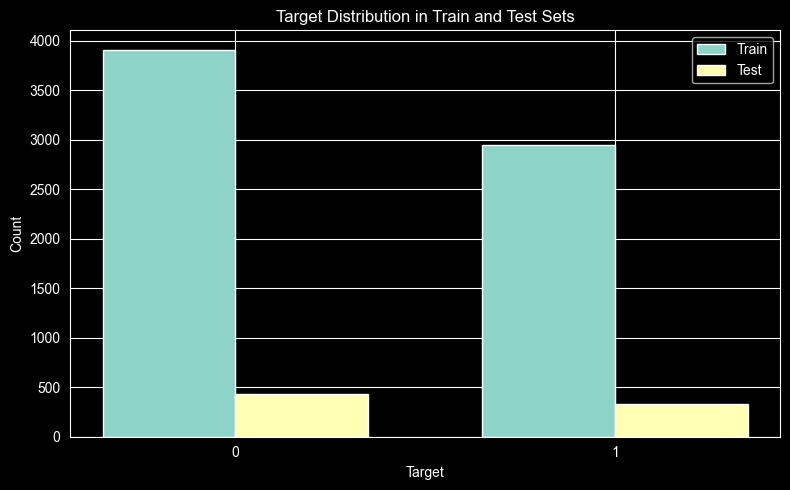

Train - Target 0: 3907 Target 1: 2944
Test - Target 0: 435 Target 1: 327
Train ratio (1/total): 0.429718289300832
Test ratio (1/total): 0.42913385826771655


In [125]:
train_counts = train['target'].value_counts().sort_index()
test_counts = test['target'].value_counts().sort_index()

x = np.arange(len(train_counts))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width / 2, train_counts.values, width, label='Train')
ax.bar(x + width / 2, test_counts.values, width, label='Test')

ax.set_xlabel('Target')
ax.set_ylabel('Count')
ax.set_title('Target Distribution in Train and Test Sets')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index)
ax.legend()
plt.tight_layout()
plt.show()

print("Train - Target 0:", train_counts[0], "Target 1:", train_counts[1])
print("Test - Target 0:", test_counts[0], "Target 1:", test_counts[1])
print("Train ratio (1/total):", train_counts[1] / (train_counts[0] + train_counts[1]))
print("Test ratio (1/total):", test_counts[1] / (test_counts[0] + test_counts[1]))

The dataset is imbalanced. Target 1 represents ~43% of the data, while target 0 represents ~57%.

# Question 2

In [126]:
train.drop(columns=['id', 'location'], inplace=True)

In [127]:
train.columns

Index(['keyword', 'text', 'target'], dtype='object')

In [128]:
test.drop(columns=['id', 'location'], inplace=True)

In [129]:
test.columns

Index(['keyword', 'text', 'target'], dtype='object')

In [130]:
train.isna().sum()

keyword    54
text        0
target      0
dtype: int64

In [131]:
train['keyword'] = train['keyword'].fillna('null')
test['keyword'] = test['keyword'].fillna('null')

In [132]:
train.isna().sum()

keyword    0
text       0
target     0
dtype: int64

In [133]:
train['inputs'] = train['keyword'] + ' ' + train['text']
test['inputs'] = test['keyword'] + ' ' + test['text']

In [134]:
train.head()

,keyword,text,target,inputs
6669,threat,Meek Mill responds to DrakeÛªs OVO Fest set w...,1,threat Meek Mill responds to DrakeÛªs OVO Fes...
3940,flood,survived the plague\nfloated the flood\njust p...,0,flood survived the plague\nfloated the flood\n...
7217,weapons,#Kick Hendrixonfire @'=BLACKCATS= | BIG NOOB ...,0,weapons #Kick Hendrixonfire @'=BLACKCATS= | B...
2234,deluge,Vince McMahon once again a billionaire: I reme...,0,deluge Vince McMahon once again a billionaire:...
4233,hazardous,Is it possible to sneak into a hospital so I c...,0,hazardous Is it possible to sneak into a hospi...


# Question 3

In [135]:
def preprocess_tweets(text_column: pd.Series) -> pd.Series:
    return (
        text_column
        .apply(removeUnicode)  # removes non-ascii noise that doesn't contribute to emergency classification
        .apply(replaceURL)  # normalizes urls to prevent overfitting to specific domains
        .apply(replaceAtUser)  # username doesn't matter, only that someone is mentioned
        .apply(removeEmoticons)  # removes emoticons that don't add semantic value for disaster detection
        .apply(replaceContraction)  # expands contractions to improve word matching and consistency
        .apply(replaceMultiExclamationMark)  # converts repeated exclamation marks to a single token
        .apply(replaceMultiQuestionMark)  # converts repeated question marks to a single token
        .apply(replaceMultiStopMark)  # converts repeated periods to a single token
        .str.lower()  # converts to lowercase for case-insensitive matching
        .apply(removeNumbers)  # removes numbers that don't contribute to emergency classification
    )

In [136]:
train['inputs'] = preprocess_tweets(train['inputs'])
test['inputs'] = preprocess_tweets(test['inputs'])

In [137]:
train['inputs'].head()

6669    threat meek mill responds to drakes ovo fest s...
3940    flood survived the plague\nfloated the flood\n...
7217    weapons kick hendrixonfire  atuser | big noob ...
2234    deluge vince mcmahon once again a billionaire ...
4233    hazardous is it possible to sneak into a hospi...
Name: inputs, dtype: object

# Question 4

In [138]:
X_train = train['inputs'].values
y_train = train['target'].values

X_test = test['inputs'].values
y_test = test['target'].values

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6851,)
y_train shape: (6851,)
X_test shape: (762,)
y_test shape: (762,)


# Question 5

In [139]:
tf_idf = TfidfVectorizer()
X_train = tf_idf.fit_transform(X_train)
X_test = tf_idf.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (6851, 13527)
X_test shape: (762, 13527)


# Question 6

In [140]:
svm_linear = LinearSVC()
svm_linear.fit(X_train, y_train)

y_train_pred = svm_linear.predict(X_train)
y_test_pred = svm_linear.predict(X_test)

print("Train Metrics:")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("F1:", f1_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall:", recall_score(y_train, y_train_pred))

print("\nTest Metrics:")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("F1:", f1_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))

Train Metrics:
Accuracy: 0.9616114435848782
F1: 0.9543482034369033
Precision: 0.9758608448704296
Recall: 0.9337635869565217

Test Metrics:
Accuracy: 0.7979002624671916
F1: 0.7578616352201258
Precision: 0.7799352750809061
Recall: 0.7370030581039755


Recall is the most important metric for this emergency detection system. It measures how many actual emergencies we detect. Missing a real disaster (false negative) has serious consequences, while a false alarm (false positive) is just inconvenient. Better to send unnecessary 112 messages than miss real emergencies.

# Question 7

In [141]:
# pca with 95% variance
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train.toarray())
X_test_pca = pca.transform(X_test.toarray())

print("original shape:", X_train.shape)
print("pca shape:", X_train_pca.shape)
print("n_components:", pca.n_components_)
print("explained variance:", pca.explained_variance_ratio_.sum())

original shape: (6851, 13527)
pca shape: (6851, 3725)
n_components: 3725
explained variance: 0.950016682872343


In [142]:
svm_linear_pca = LinearSVC()
svm_linear_pca.fit(X_train_pca, y_train)

y_train_pred_linear_pca = svm_linear_pca.predict(X_train_pca)
y_test_pred_linear_pca = svm_linear_pca.predict(X_test_pca)

print("LinearSVC with PCA - train:")
print("Accuracy:", accuracy_score(y_train, y_train_pred_linear_pca))
print("F1:", f1_score(y_train, y_train_pred_linear_pca))
print("Precision:", precision_score(y_train, y_train_pred_linear_pca))
print("Recall:", recall_score(y_train, y_train_pred_linear_pca))

print("\nLinearSVC with PCA - test:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_linear_pca))
print("F1:", f1_score(y_test, y_test_pred_linear_pca))
print("Precision:", precision_score(y_test, y_test_pred_linear_pca))
print("Recall:", recall_score(y_test, y_test_pred_linear_pca))

LinearSVC with PCA - train:
Accuracy: 0.9381112246387389
F1: 0.9257443082311734
Precision: 0.955531453362256
Recall: 0.8977581521739131

LinearSVC with PCA - test:
Accuracy: 0.8083989501312336
F1: 0.7704402515723271
Precision: 0.7928802588996764
Recall: 0.7492354740061162


In [143]:
svm_rbf_pca = SVC(kernel='rbf')
svm_rbf_pca.fit(X_train_pca, y_train)

y_train_pred_rbf_pca = svm_rbf_pca.predict(X_train_pca)
y_test_pred_rbf_pca = svm_rbf_pca.predict(X_test_pca)

print("SVC RBF with PCA - train:")
print("Accuracy:", accuracy_score(y_train, y_train_pred_rbf_pca))
print("F1:", f1_score(y_train, y_train_pred_rbf_pca))
print("Precision:", precision_score(y_train, y_train_pred_rbf_pca))
print("Recall:", recall_score(y_train, y_train_pred_rbf_pca))

print("\nSVC RBF with PCA - test:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_rbf_pca))
print("F1:", f1_score(y_test, y_test_pred_rbf_pca))
print("Precision:", precision_score(y_test, y_test_pred_rbf_pca))
print("Recall:", recall_score(y_test, y_test_pred_rbf_pca))

SVC RBF with PCA - train:
Accuracy: 0.9439497883520654
F1: 0.9321074964639321
Precision: 0.971976401179941
Recall: 0.8953804347826086

SVC RBF with PCA - test:
Accuracy: 0.8123359580052494
F1: 0.7748031496062993
Precision: 0.7987012987012987
Recall: 0.7522935779816514


RBF kernel performs slightly better than linear on test data. PCA reduced from 13k to 3.7k features while keeping 95% variance

# Question 8

In [144]:
# gamma values
n_features = X_train_pca.shape[1]
X_var = X_train_pca.var()

gamma_scale = 1 / (n_features * X_var)
gamma_auto = 1 / n_features

print("gamma 'scale':", gamma_scale)
print("gamma 'auto':", gamma_auto)

gamma 'scale': 1.0672266633232967
gamma 'auto': 0.00026845637583892615


In [145]:
# train svc with gamma='auto'
svm_rbf_auto = SVC(kernel='rbf', gamma='auto')
svm_rbf_auto.fit(X_train_pca, y_train)

y_train_pred_rbf_auto = svm_rbf_auto.predict(X_train_pca)
y_test_pred_rbf_auto = svm_rbf_auto.predict(X_test_pca)

print("SVC RBF gamma='auto' - train:")
print("Accuracy:", accuracy_score(y_train, y_train_pred_rbf_auto))
print("F1:", f1_score(y_train, y_train_pred_rbf_auto, zero_division=0))
print("Precision:", precision_score(y_train, y_train_pred_rbf_auto, zero_division=0))
print("Recall:", recall_score(y_train, y_train_pred_rbf_auto, zero_division=0))

print("\nSVC RBF gamma='auto' - test:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_rbf_auto))
print("F1:", f1_score(y_test, y_test_pred_rbf_auto, zero_division=0))
print("Precision:", precision_score(y_test, y_test_pred_rbf_auto, zero_division=0))
print("Recall:", recall_score(y_test, y_test_pred_rbf_auto, zero_division=0))

print("\nunique predictions train:", np.unique(y_train_pred_rbf_auto))
print("unique predictions test:", np.unique(y_test_pred_rbf_auto))

SVC RBF gamma='auto' - train:
Accuracy: 0.570281710699168
F1: 0.0
Precision: 0.0
Recall: 0.0

SVC RBF gamma='auto' - test:
Accuracy: 0.5708661417322834
F1: 0.0
Precision: 0.0
Recall: 0.0

unique predictions train: [0]
unique predictions test: [0]


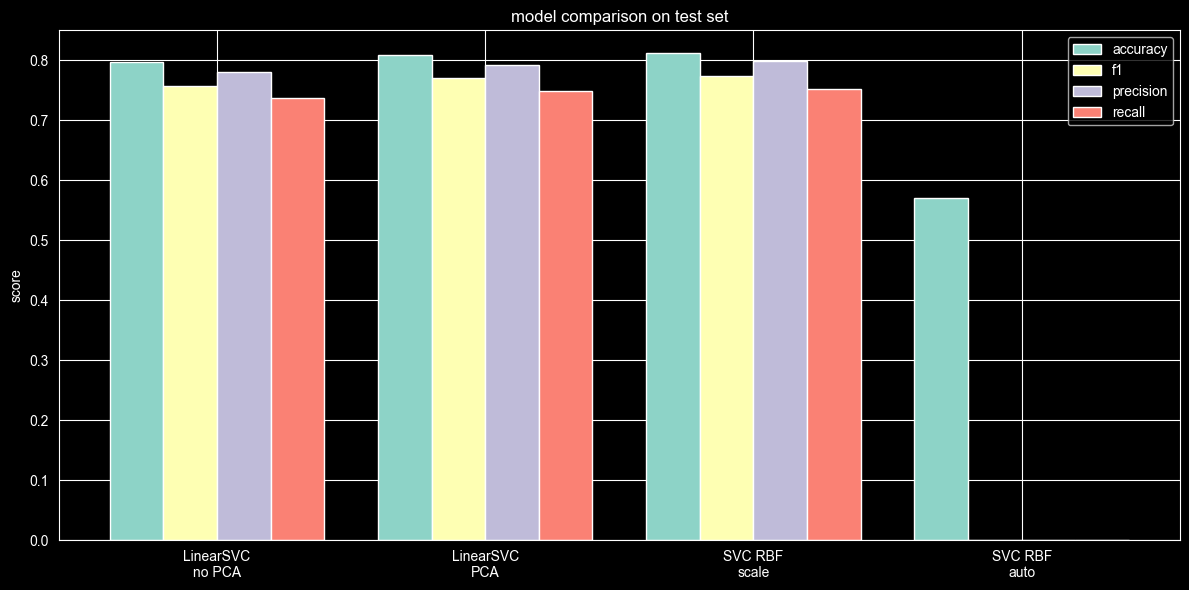

In [146]:
# compare all 4 models
models = ['LinearSVC\nno PCA', 'LinearSVC\nPCA', 'SVC RBF\nscale', 'SVC RBF\nauto']

accuracy = [
    accuracy_score(y_test, y_test_pred),
    accuracy_score(y_test, y_test_pred_linear_pca),
    accuracy_score(y_test, y_test_pred_rbf_pca),
    accuracy_score(y_test, y_test_pred_rbf_auto)
]

f1 = [
    f1_score(y_test, y_test_pred),
    f1_score(y_test, y_test_pred_linear_pca),
    f1_score(y_test, y_test_pred_rbf_pca),
    f1_score(y_test, y_test_pred_rbf_auto, zero_division=0)
]

precision = [
    precision_score(y_test, y_test_pred),
    precision_score(y_test, y_test_pred_linear_pca),
    precision_score(y_test, y_test_pred_rbf_pca),
    precision_score(y_test, y_test_pred_rbf_auto, zero_division=0)
]

recall = [
    recall_score(y_test, y_test_pred),
    recall_score(y_test, y_test_pred_linear_pca),
    recall_score(y_test, y_test_pred_rbf_pca),
    recall_score(y_test, y_test_pred_rbf_auto, zero_division=0)
]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 1.5 * width, accuracy, width, label='accuracy')
ax.bar(x - 0.5 * width, f1, width, label='f1')
ax.bar(x + 0.5 * width, precision, width, label='precision')
ax.bar(x + 1.5 * width, recall, width, label='recall')

ax.set_ylabel('score')
ax.set_title('model comparison on test set')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
plt.tight_layout()
plt.show()

Gamma='auto' performs poorly, only predicts class 0. With 3725 features, gamma=1/3725 is too small, making the rbf kernel too smooth to learn. gamma='scale' works better because it considers data variance, not just feature count.

# Question 9

In [147]:
gnb = GaussianNB()
gnb.fit(X_train.toarray(), y_train)

y_train_pred_gnb = gnb.predict(X_train.toarray())
y_test_pred_gnb = gnb.predict(X_test.toarray())

print("Gaussian Naive Bayes - train:")
print("Accuracy:", accuracy_score(y_train, y_train_pred_gnb))
print("F1:", f1_score(y_train, y_train_pred_gnb))
print("Precision:", precision_score(y_train, y_train_pred_gnb))
print("Recall:", recall_score(y_train, y_train_pred_gnb))

print("\nGaussian Naive Bayes - test:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_gnb))
print("F1:", f1_score(y_test, y_test_pred_gnb))
print("Precision:", precision_score(y_test, y_test_pred_gnb))
print("Recall:", recall_score(y_test, y_test_pred_gnb))

Gaussian Naive Bayes - train:
Accuracy: 0.8797255875054737
F1: 0.8772348033373063
Precision: 0.7813163481953291
Recall: 1.0

Gaussian Naive Bayes - test:
Accuracy: 0.6181102362204725
F1: 0.6429447852760736
Precision: 0.5368852459016393
Recall: 0.8012232415902141
